#Exploratory Data Analysis in Python

##Importing Libraries for Iris Dataset Analysis


In [ ]:
# Load Iris Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
import numpy as np
from scipy import stats

In [ ]:
pip install pandas matplotlib seaborn scikit-learn

## Load and Display Iris Dataset

In [ ]:
# Load Iris Dataset
iris = load_iris()
iris_df = pd.DataFrame(data=np.c_[iris['data'], iris['target']], columns=iris['feature_names'] + ['target']) # Fixed np.c_

print(iris_df.head()) #R: dim(iris_df)
print(iris_df.tail()) #R: dim(iris_df)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0     0.0  
1     0.0  
2     0.0  
3     0.0  
4     0.0  
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0        

##Dataset Overview

In [ ]:
#Dataset Overview
print(iris_df.info()) #R: str(iris_df)
print("Data Dimensions: ", iris_df.shape) #R: dim(iris_df)
print("Column Names", iris_df.columns) #R: names(iris_df)
print("Number of Rows", len(iris_df)) #R: nrows(iris_df)
print("Number of Columns", len(iris_df.columns)) #R: columns(iris_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    float64
dtypes: float64(5)
memory usage: 6.0 KB
None
Data Dimensions:  (150, 5)
Column Names Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')
Number of Rows 150
Number of Columns 5


## Target Variable Analysis

target
0.0    50
1.0    50
2.0    50
Name: count, dtype: int64


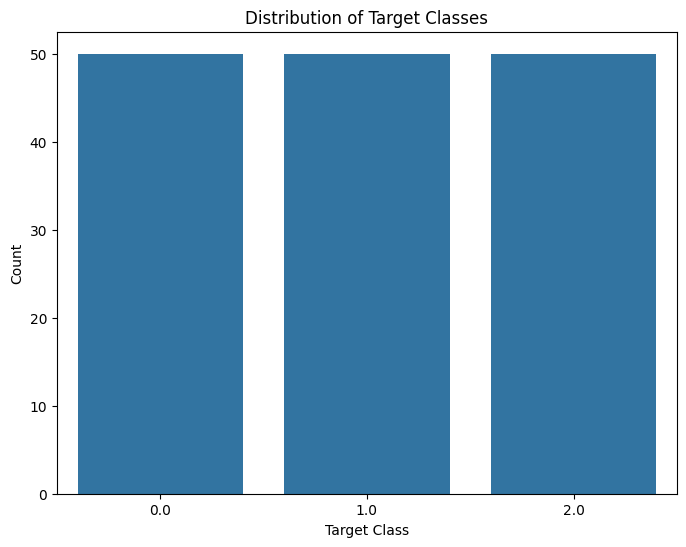

In [ ]:
#table summary for target

print(iris_df['target'].value_counts()) #R: table(iris_df$target)

#draw bar plot
plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=iris_df)
plt.title("Distribution of Target Classes")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.show()

## Descriptive Statistics on Sepal Length

In [ ]:
#Descriptive Statistics
print(iris_df.describe()) #R: summary(iris_df)

#Extract Specific Statistics for Sepal Length
mean_sepal_length = iris_df['sepal length (cm)'].mean() #R: mean(iris_df$sepal_length)
median_sepal_length = iris_df['sepal length (cm)'].median() #R: median(iris_df$sepal_length)
std_sepal_length = iris_df['sepal length (cm)'].std() #R: sd(iris_df$sepal_length)
var_sepal_length = iris_df['sepal length (cm)'].var() #R: var(iris_df$sepal_length)
min_sepal_length = iris_df['sepal length (cm)'].min() #R: min(iris_df$sepal_length)
max_sepal_length = iris_df['sepal length (cm)'].max()  #R: max(iris_df$sepal_length)
q1_sepal_length = iris_df['sepal length (cm)'].quantile(0.25) #R: quantile(iris_df$sepal_length, 0.25)
q3_sepal_length = iris_df['sepal length (cm)'].quantile(0.75) #R: quantile(iris_df$sepal_length, 0.75)

print("Mean Sepal Length:", mean_sepal_length)
print("Median Sepal Length:", median_sepal_length)
print("Standard Deviation Sepal Length:", std_sepal_length)
print("Variance Sepal Length:", var_sepal_length)
print("Minimum Sepal Length:", min_sepal_length)
print("Maximum Sepal Length:", max_sepal_length)
print("First Quartile Sepal Length:", q1_sepal_length)
print("Third Quartile Sepal Length:", q3_sepal_length)

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  
Mean Sepal Length: 5.843333333333334
Median Sepal Length: 5.8
Standard D

Lower Bound: 3.1499999999999986
Upper Bound: 8.350000000000001
Outliers based on IQR: Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), target]
Index: []


Text(0.5, 0, 'Sepal Length (cm)')

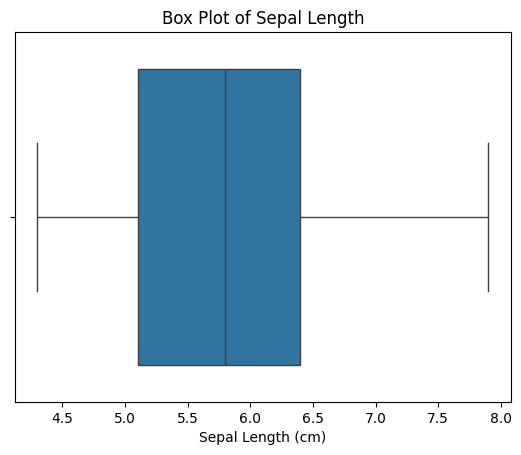

In [ ]:
#Use IQR to detect outliers in sepal length

lower_bound = q1_sepal_length - 1.5 * (q3_sepal_length - q1_sepal_length)
upper_bound = q3_sepal_length + 1.5 * (q3_sepal_length - q1_sepal_length)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers_iqr = iris_df[(iris_df['sepal length (cm)'] < lower_bound) | (iris_df['sepal length (cm)'] > upper_bound)]
print("Outliers based on IQR:", outliers_iqr)

#generate box plot for sepal length to highlight outliers
outliers = iris_df[(iris_df['sepal length (cm)'] < lower_bound) | (iris_df['sepal length (cm)'] > upper_bound)]
sns.boxplot(x=iris_df['sepal length (cm)'])
plt.title("Box Plot of Sepal Length")
plt.xlabel("Sepal Length (cm)")


--- Analysis for sepal length (cm) ---
Shapiro-Wilk Test Statistic:  0.9760902723490532
Shapiro-Wilk p-value:  0.010181161454691156
The data does not appear to be normally distributed.
Lower Bound:  3.3591349493997447
Upper Bound:  8.327531717266922
No outliers found using Standard Deviation.


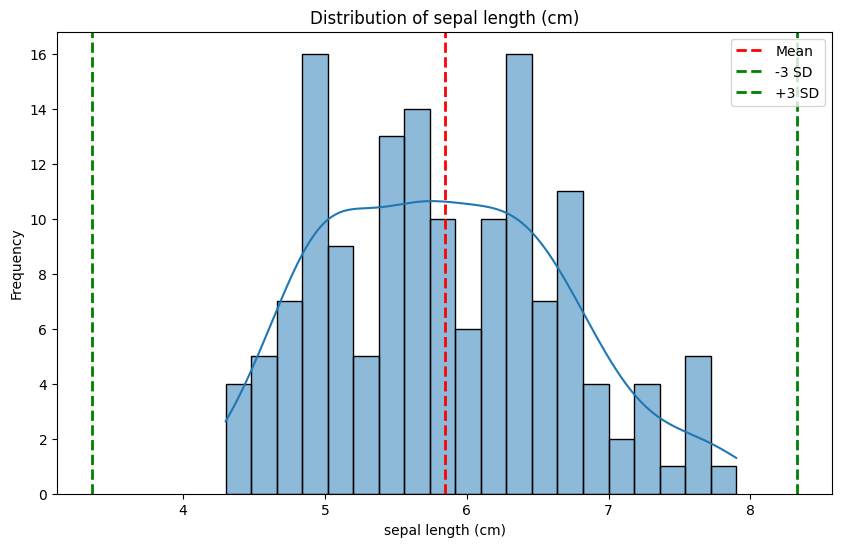


--- Analysis for sepal width (cm) ---
Shapiro-Wilk Test Statistic:  0.9849178695056319
Shapiro-Wilk p-value:  0.10115426916130282
The data appears to be normally distributed.
Lower Bound:  1.7497344785232398
Upper Bound:  4.3649321881434275
Outliers using Standard Deviation:      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
15                5.7               4.4                1.5               0.4   

    target  
15     0.0  


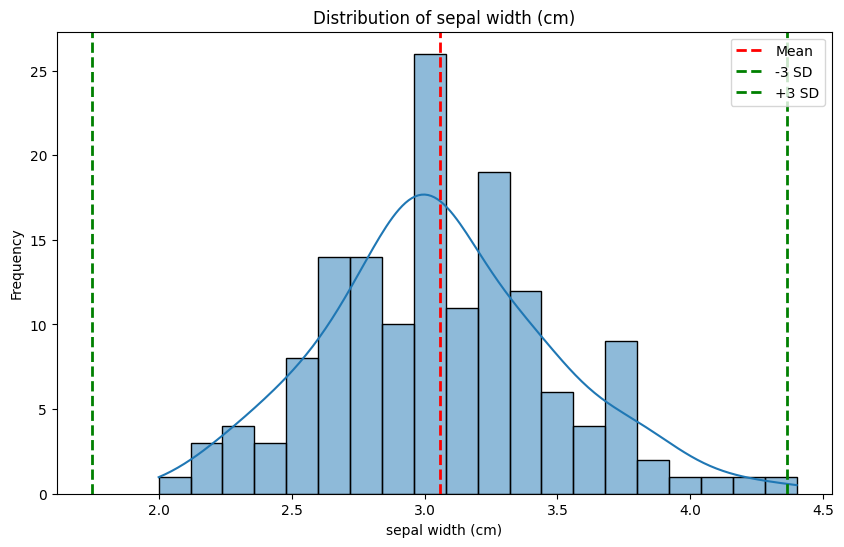


--- Analysis for petal length (cm) ---
Shapiro-Wilk Test Statistic:  0.8762680554631075
Shapiro-Wilk p-value:  7.412263135173186e-10
The data does not appear to be normally distributed.
Lower Bound:  -1.5378946997783998
Upper Bound:  9.0538946997784
No outliers found using Standard Deviation.


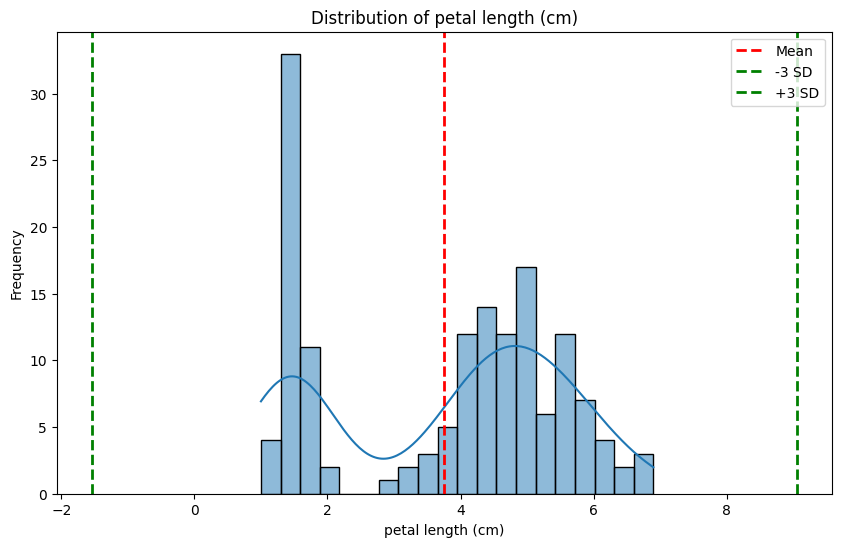


--- Analysis for petal width (cm) ---
Shapiro-Wilk Test Statistic:  0.9018349381915991
Shapiro-Wilk p-value:  1.680465210314913e-08
The data does not appear to be normally distributed.
Lower Bound:  -1.087379673547706
Upper Bound:  3.486046340214373
No outliers found using Standard Deviation.


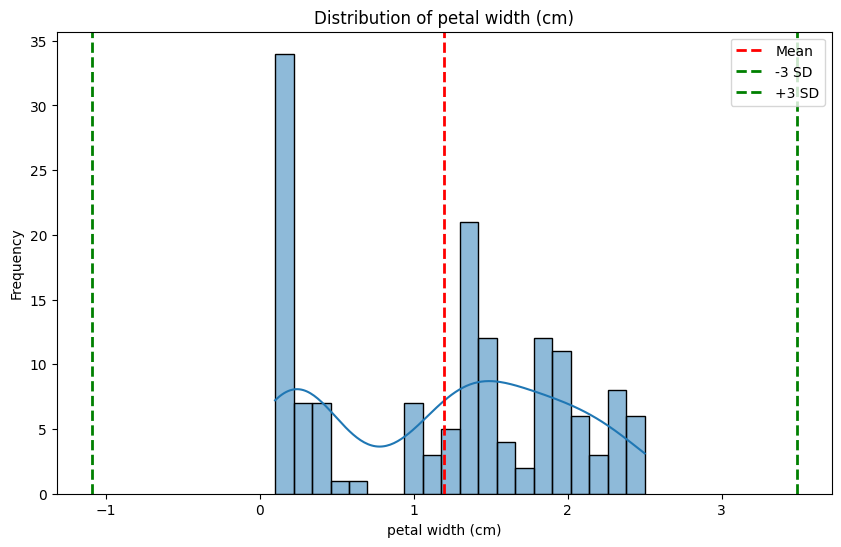

In [ ]:
numerical_features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

for feature in numerical_features:
    print(f"\n--- Analysis for {feature} ---")

    # Shapiro-Wilk Test for Normality
    data = iris_df[feature]
    shapiro_test = stats.shapiro(data)
    print("Shapiro-Wilk Test Statistic: ", shapiro_test.statistic)
    print("Shapiro-Wilk p-value: ", shapiro_test.pvalue)

    if shapiro_test.pvalue > 0.05:
        print("The data appears to be normally distributed.")
    else:
        print("The data does not appear to be normally distributed.")

    # Outlier Detection using Mean and Standard Deviation
    mean = data.mean()
    std = data.std()
    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std

    print("Lower Bound: ", lower_bound)
    print("Upper Bound: ", upper_bound)

    outliers_sd = iris_df[(iris_df[feature] < lower_bound) | (iris_df[feature] > upper_bound)]
    if outliers_sd.empty:
        print("No outliers found using Standard Deviation.")
    else:
        print("Outliers using Standard Deviation: ", outliers_sd)

    # Histogram with Mean and 3 SD Lines
    plt.figure(figsize=(10, 6))
    sns.histplot(data, bins=20, kde=True)
    plt.axvline(mean, color='red', linestyle='dashed', linewidth=2, label='Mean')
    plt.axvline(lower_bound, color='green', linestyle='dashed', linewidth=2, label='-3 SD')
    plt.axvline(upper_bound, color='green', linestyle='dashed', linewidth=2, label='+3 SD')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {feature}')
    plt.legend()
    plt.show()


--- Analysis for sepal length (cm) ---
Lower Bound:  3.1499999999999986
Upper Bound:  8.350000000000001
Outliers using IQR:  Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), target]
Index: []


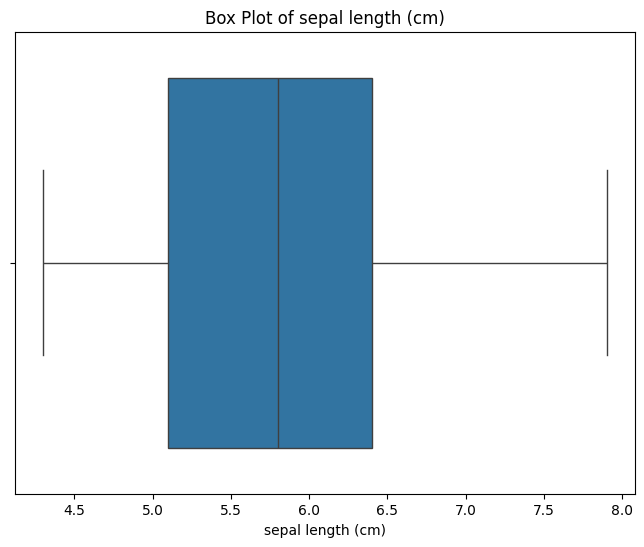


--- Analysis for sepal width (cm) ---
Lower Bound:  2.05
Upper Bound:  4.05
Outliers using IQR:      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
15                5.7               4.4                1.5               0.4   
32                5.2               4.1                1.5               0.1   
33                5.5               4.2                1.4               0.2   
60                5.0               2.0                3.5               1.0   

    target  
15     0.0  
32     0.0  
33     0.0  
60     1.0  


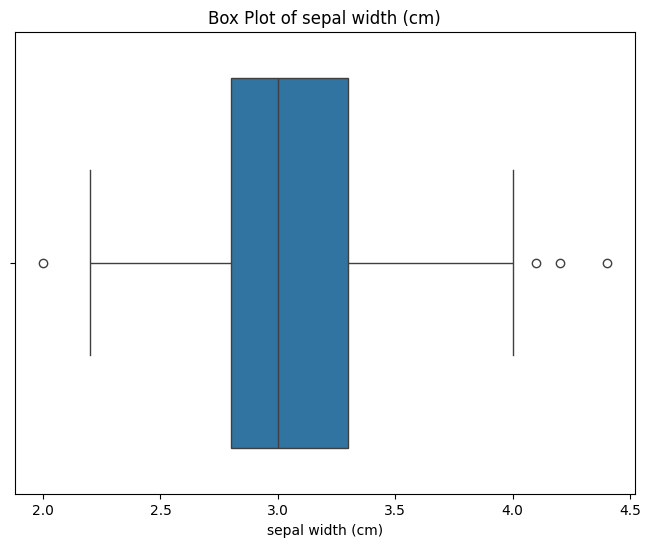


--- Analysis for petal length (cm) ---
Lower Bound:  -3.649999999999999
Upper Bound:  10.349999999999998
Outliers using IQR:  Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), target]
Index: []


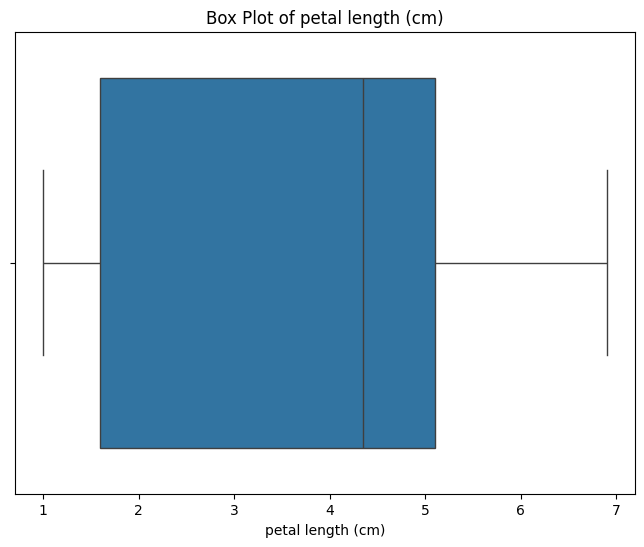


--- Analysis for petal width (cm) ---
Lower Bound:  -1.95
Upper Bound:  4.05
Outliers using IQR:  Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), target]
Index: []


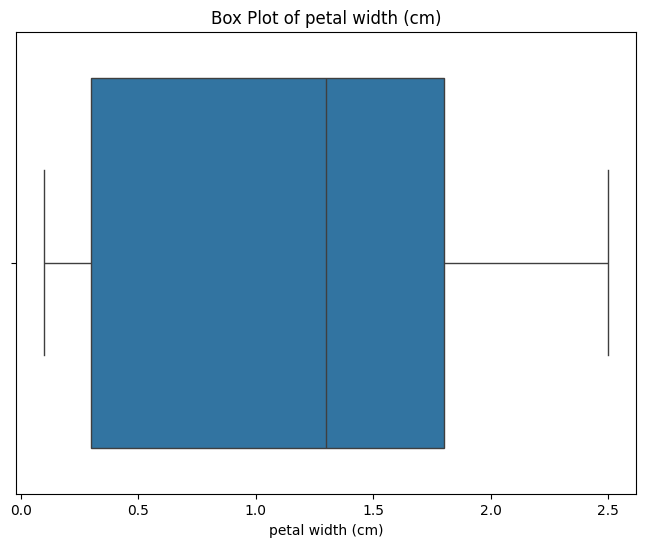

In [ ]:
for feature in numerical_features:
    print(f"\n--- Analysis for {feature} ---")

    # Calculate IQR and Bounds
    Q1 = iris_df[feature].quantile(0.25)
    Q3 = iris_df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print("Lower Bound: ", lower_bound)
    print("Upper Bound: ", upper_bound)

    # Detect Outliers
    outliers_iqr = iris_df[(iris_df[feature] < lower_bound) | (iris_df[feature] > upper_bound)]
    print("Outliers using IQR: ", outliers_iqr)

    # Generate Box Plot
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=iris_df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.show()

##Handling Missing Values

In [ ]:
#Check for Missing Values
print(iris_df.isnull().sum()) #R: colSums(is.na(iris_df))

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


##Bivariate Analysis

###Bivariate Analysis (Categorical VS Numerical)
T-test
Kruskal Wallis
Anova
Grouped Plots

In [ ]:
#Anova Test for Sepal Length
from scipy.stats import f_oneway

groups = [iris_df[iris_df['target'] == i]['sepal length (cm)'] for i in iris_df['target'].unique()]
f_statistic, p_value = f_oneway(*groups)

print("ANOVA Test Results:")
print("F-statistic:", f_statistic)
print("P-value:", p_value)

if p_value < 0.05:
    print("The means of the groups are significantly different.")
else:
    print("The means of the groups are not significantly different.")

ANOVA Test Results:
F-statistic: 119.26450218450468
P-value: 1.6696691907693826e-31
The means of the groups are significantly different.


In [ ]:
# T-test for Sepal Length

from scipy.stats import ttest_ind

group1 = iris_df[iris_df['target'] == 0]['sepal length (cm)']
group2 = iris_df[iris_df['target'] == 1]['sepal length (cm)']

t_statistic, p_value = ttest_ind(group1, group2)

print("T-test Results:")
print("T-statistic:", t_statistic)
print("P-value:", p_value)

if p_value < 0.05:
    print("There is a significant difference in sepal length between the two groups.")
else:
    print("There is no significant difference in sepal length between the two groups.")

T-test Results:
T-statistic: -10.52098626754911
P-value: 8.985235037487079e-18
There is a significant difference in sepal length between the two groups.


In [ ]:
# Kruskal-Wallis Test for Sepal Length
from scipy.stats import kruskal

groups = [iris_df[iris_df['target'] == i]['sepal length (cm)'] for i in iris_df['target'].unique()]

h_statistic, p_value = kruskal(*groups)

print("\nKruskal-Wallis Test Results:")
print("H-statistic:", h_statistic)
print("P-value:", p_value)

if p_value < 0.05:
    print("There are significant differences between the groups.")
else:
    print("There are no significant differences between the groups.")


Kruskal-Wallis Test Results:
H-statistic: 96.93743600064833
P-value: 8.91873433246198e-22
There are significant differences between the groups.



Analysis for sepal length (cm)

ANOVA Test for sepal length (cm)
F-statistic: 119.26450218450468
p-value: 1.6696691907693826e-31
There is a significant difference in sepal length (cm) between the three species.

Kruskal-Wallis Test for sepal length (cm)
F-statistic: 96.93743600064833
p-value: 8.91873433246198e-22
There is a significant difference in sepal length (cm) between the three species.


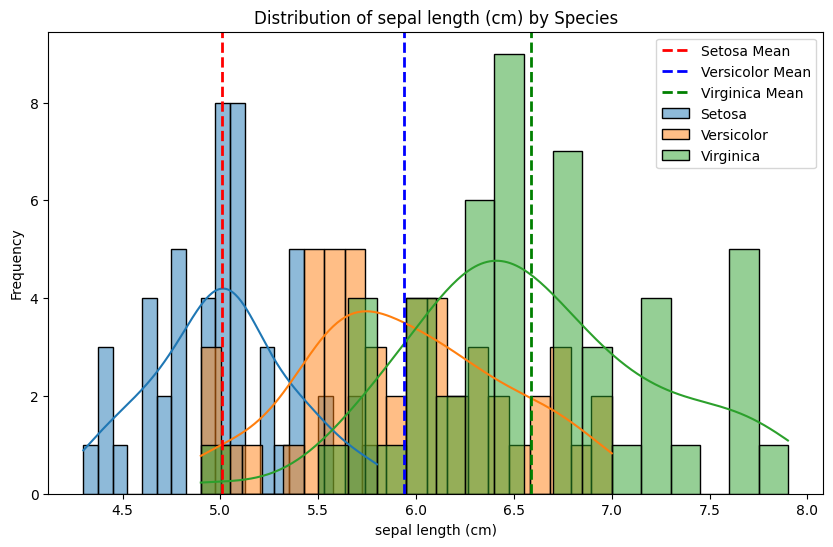

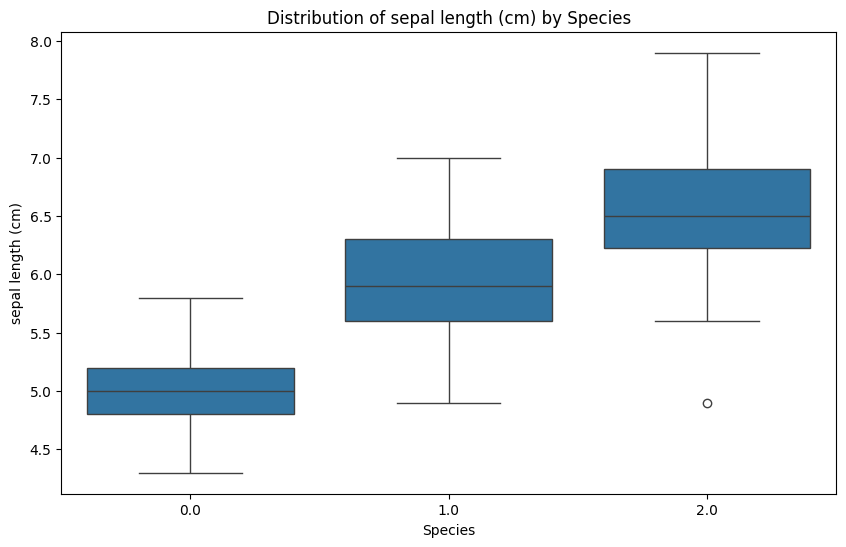


Analysis for sepal width (cm)

ANOVA Test for sepal width (cm)
F-statistic: 49.160040089612075
p-value: 4.492017133309115e-17
There is a significant difference in sepal width (cm) between the three species.

Kruskal-Wallis Test for sepal width (cm)
F-statistic: 63.571146104163795
p-value: 1.5692820940316782e-14
There is a significant difference in sepal width (cm) between the three species.


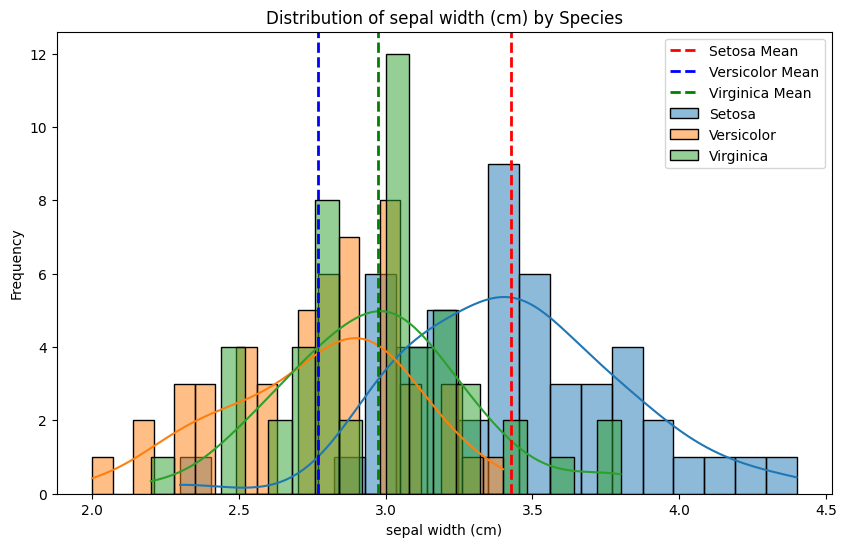

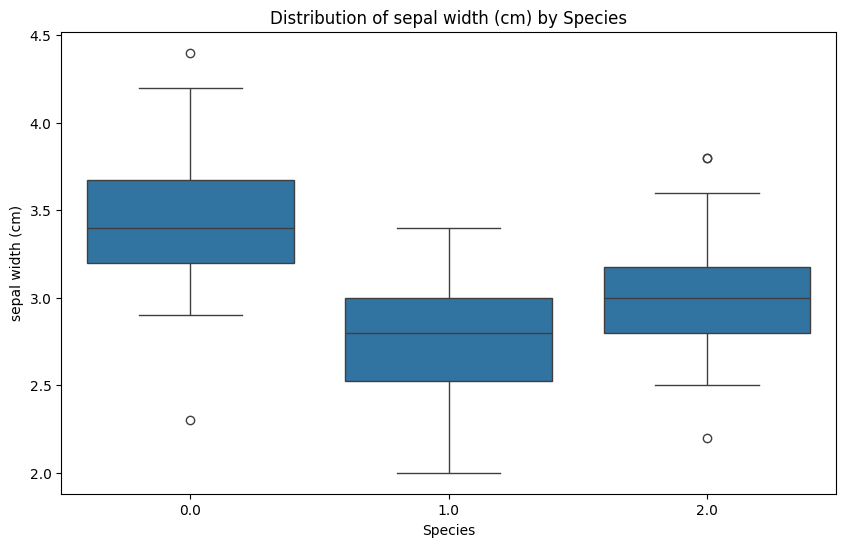


Analysis for petal length (cm)

ANOVA Test for petal length (cm)
F-statistic: 1180.161182252981
p-value: 2.8567766109615584e-91
There is a significant difference in petal length (cm) between the three species.

Kruskal-Wallis Test for petal length (cm)
F-statistic: 130.41104857977163
p-value: 4.803973591157605e-29
There is a significant difference in petal length (cm) between the three species.


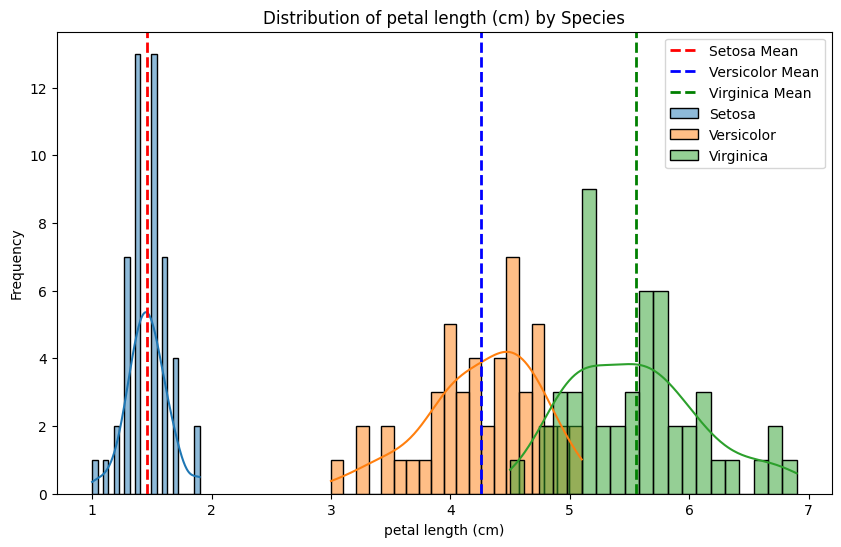

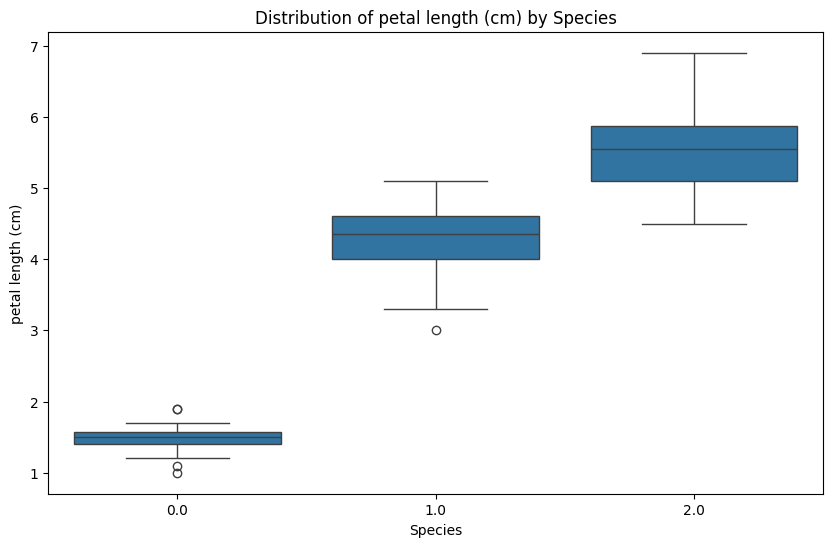


Analysis for petal width (cm)

ANOVA Test for petal width (cm)
F-statistic: 960.007146801809
p-value: 4.169445839443116e-85
There is a significant difference in petal width (cm) between the three species.

Kruskal-Wallis Test for petal width (cm)
F-statistic: 131.18537974024488
p-value: 3.261795552421968e-29
There is a significant difference in petal width (cm) between the three species.


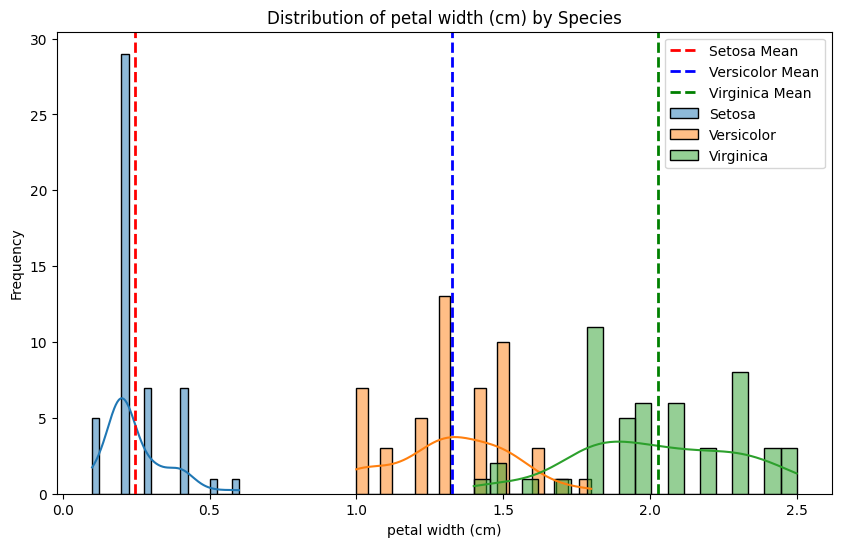

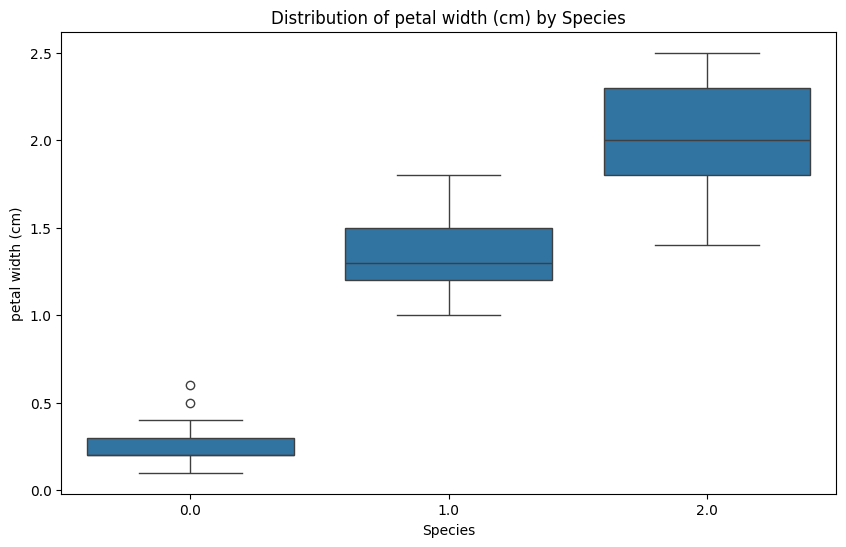

In [ ]:
def perform_analysis(df, variable_name):
    print(f"\nAnalysis for {variable_name}")

    setosa_data = df[df['target'] == 0][variable_name]
    versicolor_data = df[df['target'] == 1][variable_name]
    virginica_data = df[df['target'] == 2][variable_name]

    # ANOVA Test
    print(f"\nANOVA Test for {variable_name}")
    f_statistic, p_value = stats.f_oneway(setosa_data, versicolor_data, virginica_data)
    print("F-statistic:", f_statistic)
    print("p-value:", p_value)

    if p_value < 0.05:
        print(f"There is a significant difference in {variable_name} between the three species.")
    else:
        print(f"There is no significant difference in {variable_name} between the three species.")

    # Kruskal-Wallis Test
    print(f"\nKruskal-Wallis Test for {variable_name}")
    f_statistic, p_value = stats.kruskal(setosa_data, versicolor_data, virginica_data)
    print("F-statistic:", f_statistic)
    print("p-value:", p_value)

    if p_value < 0.05:
        print(f"There is a significant difference in {variable_name} between the three species.")
    else:
        print(f"There is no significant difference in {variable_name} between the three species.")

    # Histogram
    plt.figure(figsize=(10, 6))
    sns.histplot(setosa_data, bins=20, kde=True, label='Setosa')
    sns.histplot(versicolor_data, bins=20, kde=True, label='Versicolor')
    sns.histplot(virginica_data, bins=20, kde=True, label='Virginica')
    plt.axvline(setosa_data.mean(), color='red', linestyle='dashed', linewidth=2, label='Setosa Mean')
    plt.axvline(versicolor_data.mean(), color='blue', linestyle='dashed', linewidth=2, label='Versicolor Mean')
    plt.axvline(virginica_data.mean(), color='green', linestyle='dashed', linewidth=2, label='Virginica Mean')
    plt.xlabel(variable_name)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {variable_name} by Species')
    plt.legend()
    plt.show()

    # Boxplot
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='target', y=variable_name, data=df)  # Use the whole DataFrame
    plt.xlabel('Species')
    plt.ylabel(variable_name)
    plt.title(f'Distribution of {variable_name} by Species')
    plt.show()



# List of variables to analyze
variables = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

# Loop through each variable and perform the analysis
for variable in variables:
    perform_analysis(iris_df, variable)

###Bivariate Analysis (Categorical VS Categorical)
Table Summary
Contingency Table
Chi-square Test Statistic

In [ ]:
contingency_table = pd.crosstab(iris_df['target'], iris_df['target'])

print("Contingency Table:")
print(contingency_table)

from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-square Test Results:")
print("Chi-square statistic:", chi2)
print("P-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:", expected)

Contingency Table:
target  0.0  1.0  2.0
target               
0.0      50    0    0
1.0       0   50    0
2.0       0    0   50

Chi-square Test Results:
Chi-square statistic: 299.99999999999994
P-value: 1.0834394919478678e-63
Degrees of freedom: 4
Expected frequencies: [[16.66666667 16.66666667 16.66666667]
 [16.66666667 16.66666667 16.66666667]
 [16.66666667 16.66666667 16.66666667]]


###Bivariate Analysis Numerical VS Numerical

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


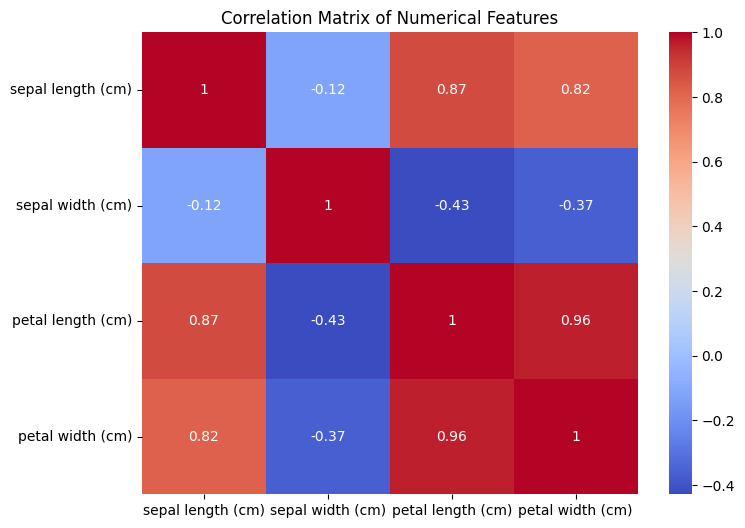

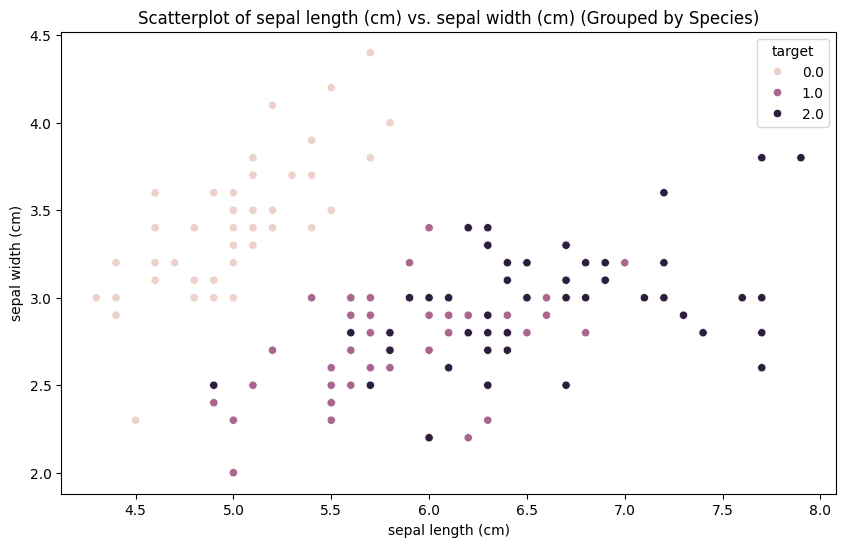

Regression Analysis for sepal length (cm) vs. sepal width (cm):
  Slope: -0.061884797964144145
  Intercept: 3.418946836103816
  R-squared: 0.013822654141080708
  p-value: 0.15189826071144782




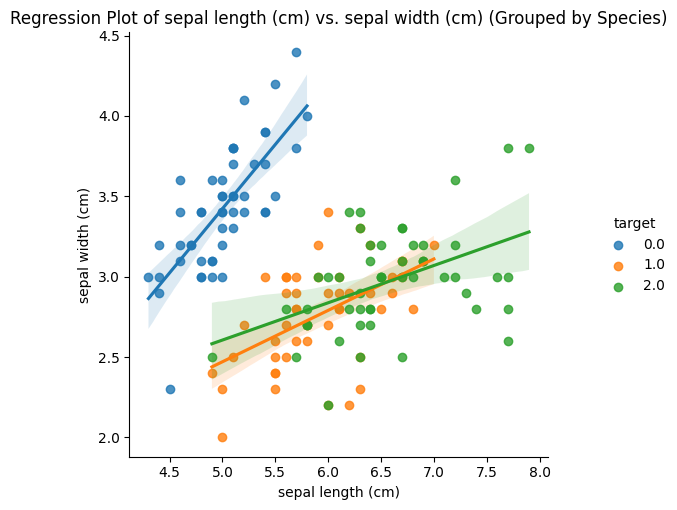

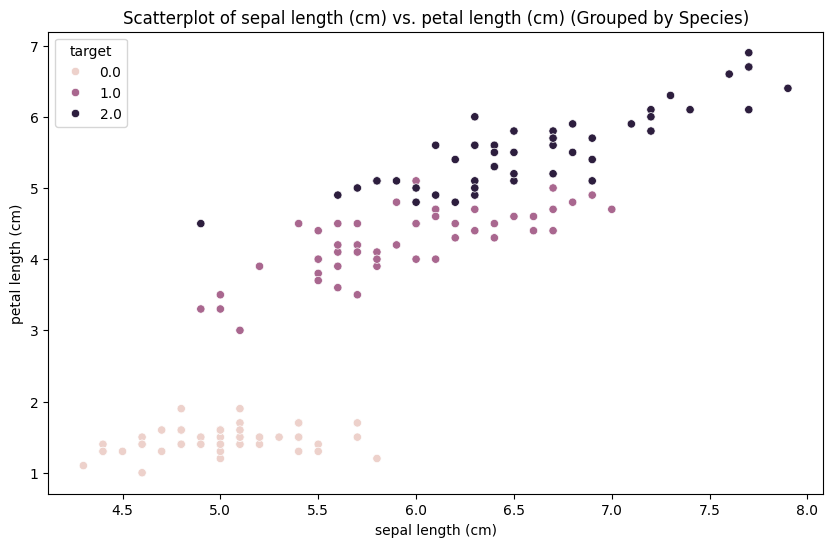

Regression Analysis for sepal length (cm) vs. petal length (cm):
  Slope: 1.858432978254842
  Intercept: -7.10144336960246
  R-squared: 0.7599546457725154
  p-value: 1.0386674194496941e-47




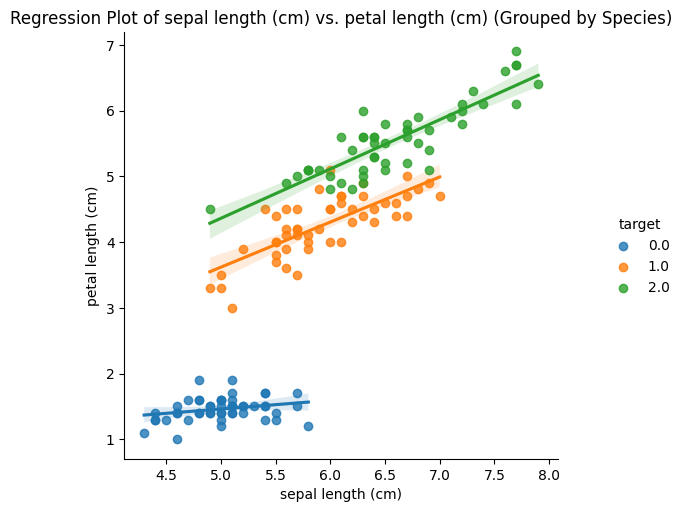

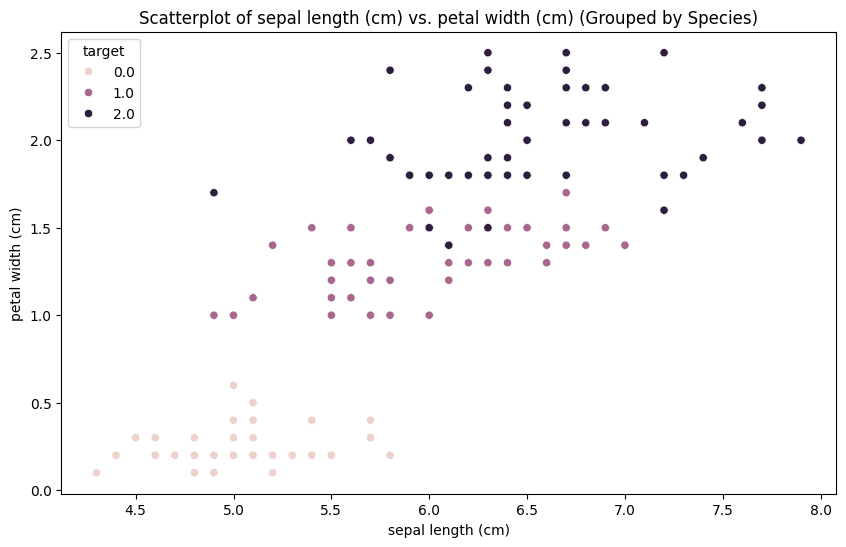

Regression Analysis for sepal length (cm) vs. petal width (cm):
  Slope: 0.7529175706758454
  Intercept: -3.2002150046491904
  R-squared: 0.6690276860464138
  p-value: 2.325498079793078e-37




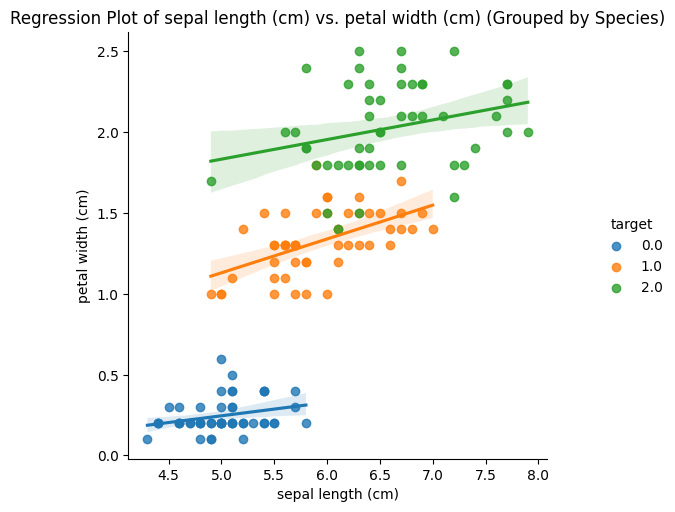

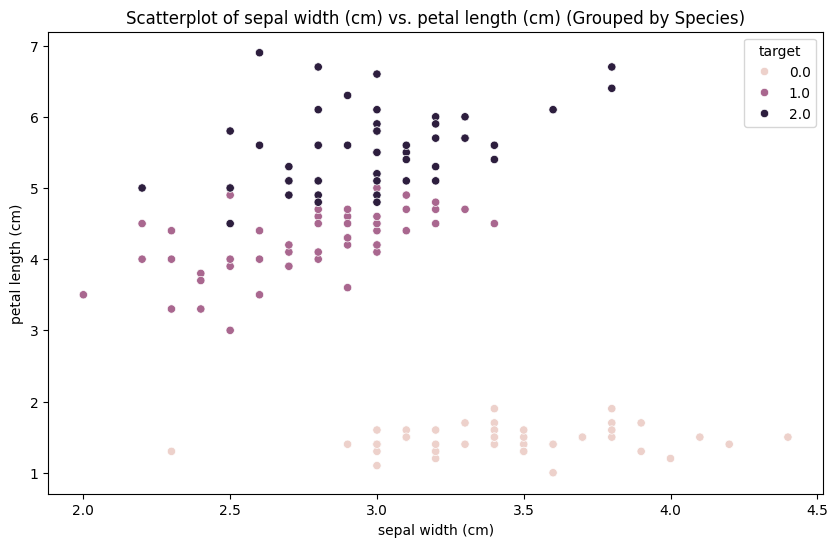

Regression Analysis for sepal width (cm) vs. petal length (cm):
  Slope: -1.7352215240553555
  Intercept: 9.063150606211908
  R-squared: 0.18356092299876356
  p-value: 4.5133142672731245e-08




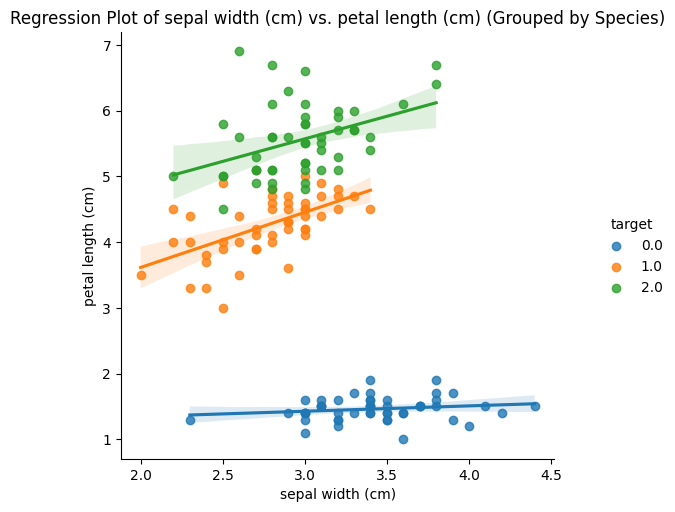

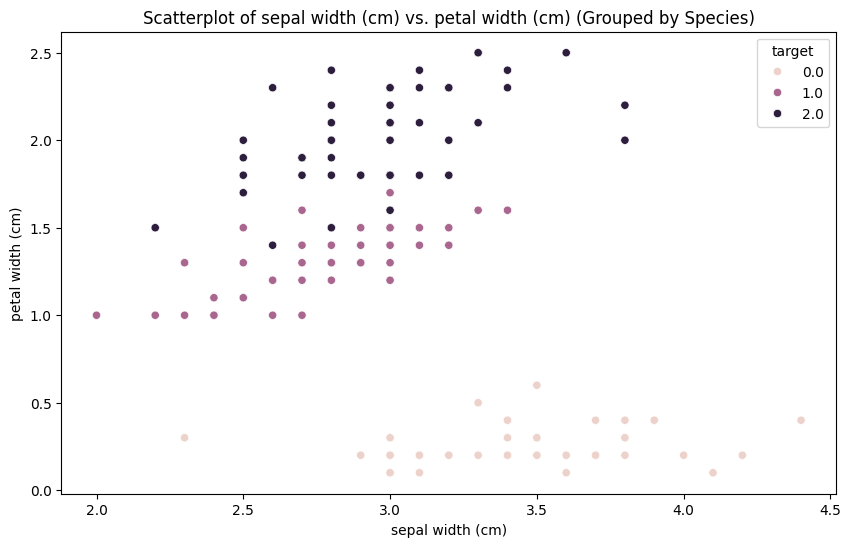

Regression Analysis for sepal width (cm) vs. petal width (cm):
  Slope: -0.6402765871258871
  Intercept: 3.1568722857062124
  R-squared: 0.1340481984756773
  p-value: 4.0732285132461815e-06




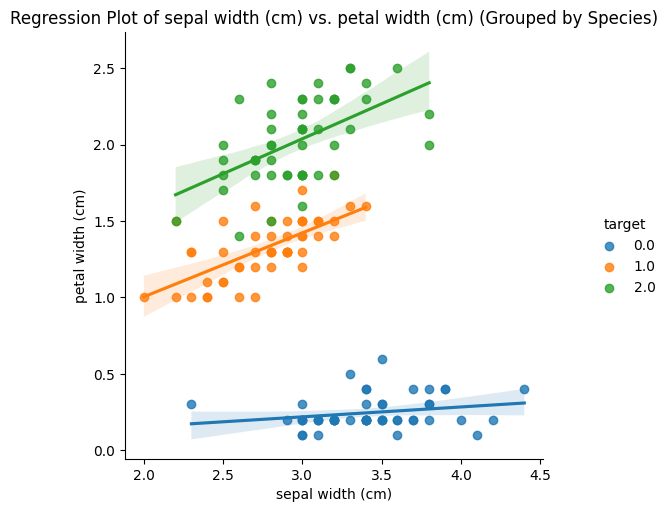

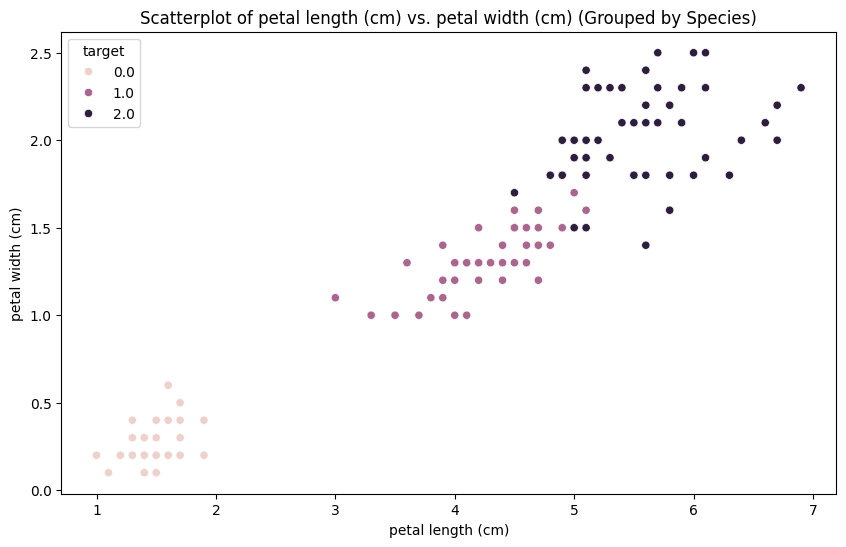

Regression Analysis for petal length (cm) vs. petal width (cm):
  Slope: 0.41575541635241114
  Intercept: -0.36307552131902776
  R-squared: 0.9271098389904932
  p-value: 4.6750039073255014e-86




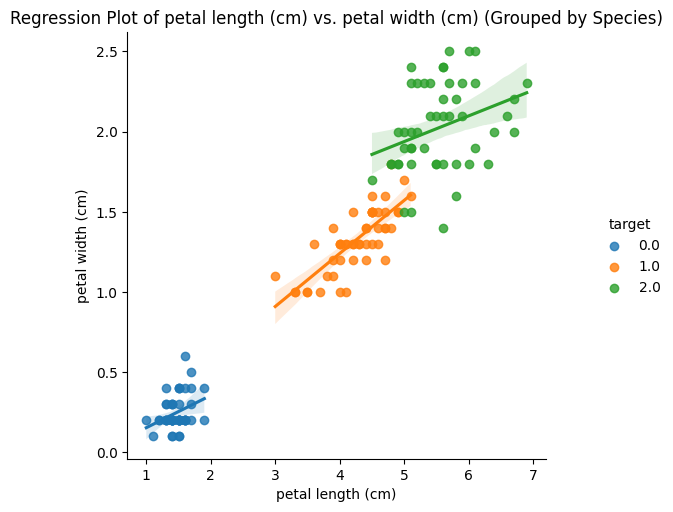

In [ ]:
# Correlation Matrix and Heatmap (already good)
correlation_matrix = iris_df[numerical_features].corr()  # Use only numerical features
print(correlation_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# Bivariate Analysis for all Numerical Pairs
for i in range(len(numerical_features)):
    for j in range(i + 1, len(numerical_features)):  # Avoid redundant pairs (e.g., petal length vs. width and width vs. length) and diagonal (variable vs itself).
        var1 = numerical_features[i]
        var2 = numerical_features[j]

        # Scatterplot grouped by species
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=var1, y=var2, hue='target', data=iris_df)
        plt.title(f"Scatterplot of {var1} vs. {var2} (Grouped by Species)")
        plt.show()

        # Regression Analysis (if appropriate - you might want to add a check for correlation strength here)
        slope, intercept, r_value, p_value, std_err = stats.linregress(iris_df[var1], iris_df[var2])
        r_squared = r_value**2
        print(f"Regression Analysis for {var1} vs. {var2}:")
        print(f"  Slope: {slope}")
        print(f"  Intercept: {intercept}")
        print(f"  R-squared: {r_squared}")
        print(f"  p-value: {p_value}")
        print("\n")

        # Regression Plot
        sns.lmplot(x=var1, y=var2, hue='target', data=iris_df, fit_reg=True)
        plt.title(f"Regression Plot of {var1} vs. {var2} (Grouped by Species)")
        plt.show()